# User guide and example for the Landlab SoilLandslider component

This notebook provides an introduction, user guide, and additional module breakdown for running models with the SoilLandslider component for landscape evolution modeling. This notebook is meant to act both as a user's Manual and as a tutorial example, written by Paul M. Morgan to accompany the following publication:

Paul M. Morgan, Benjamin Campforts, Gregory Tucker, Susannah Morey, Selina Davila Olivera, Alison Duvall. SoilLandslider: A soil landsliding component for landscape evolution modelling implemented in Landlab

While this notebook includes significant text duplicated from the publication, please refer to the publication for further figures and demonstrations. 

This user manual includes: 
* Part 1: Generating a landscape. a detailed walkthrough of the Landlab components needed to simulate a landscape with a stable soil layer
  * Part 1.1: Background on the components
  * Part 1.2: Implimentation of a model in landlab
* Part 2: An introduction and simple implimentation of the SoilLandslider component

 


*(User's Manual and example notebook written by P.M. Morgan in July 2026, and copies heavilily from the publication cited above *

## Part 1: Creating a landscape with a stable soil layer

This user manual and tutorial introduces the 'SoilLandslider' component, which allows landslides to occur that fail only the uppermost soil layer on a landscape. This requires a landscape that both has slopes steep enough to trigger landslides and a soil layer thick enough to fail. Generating such a landscape using Landlab components is not a trivial task. Part 1 of this user guide will walk through the components, and parameter choices necessary to generate such a landscape. 

Part 1 provides a detailed walk through creating a synthetic landscape with: (a)uplift, (b)weathering, (c)diffusion, and (d)fluvial erosion and deposition, while paying close attention to the input parameters that a user can choose to modify these processes. Following the models of Morgan et al., (In Prep) we also note possible values for the parameters that may correspond to the Oregon Coast Range, USA, a landscape with extensively documented soil landslides.

Skip to part 2 for more details on SoilLandslider. But part 2 requires the landscape generated in part 1 to run. Also note that this landscape may take some time to generate.


## Part 1.1: Background


### Uplift
#### Component - No component used

In our models we implement uniform uplift across the whole grid by adding elevation to the bedrock layer each timestep before updating the topographic elevation and running the erosive modules. Uplift experienced by real landscapes varies greatly from landscapes not (or no longer) uplifting to the fastest actively uplifting mountains ~6-9 mm/yr in New Zealand (Little et al., 2005) or 4-8 mm/yr in Taiwan (Hsu et al., 2016). 

#### Input Parameters 
- **Uplift rate** $U$ [uplift_rate]:
Proposed uplift values for the Oregon Coast Range vary from 0.05 mm/yr (0.00005 m/yr) to 0.3 mm/yr (0.0003 m/yr) (Struble et al., 2021); in this notebook we use an uplift value of 0.0003 m/yr or 0.3 mm/yr.

### Weathering (Soil Production)
#### Component - ExponentialWeathererIntegrated
#### Theory and governing equations
Having both bedrock and soil layers in a model necessitates a function that simulate physical and chemical weathering processes that convert cohesive bedrock into soil.
Weathering in Landlab is primarily completed using the component ExponentialWeatherer (or ExponentialWeathererIntegrated) (Barnhart et al., 2019). 
This component, uses an inverse-exponential function of soil thickness to define the weathering rate at any time step (Ahnert, 1976, Heimsath et al., 1997; Small et al., 1999). Where

$$P = P_0 e^{H / H_{WD}} \tag{Eq. 1}$$

where $P$ is the soil production rate, $P_0$ is the maximum production rate, $H$ is the vertical soil depth, and $H_0$ is a characteristic soil production decay depth.
Following this form the soil production rate is equal to the maximum weathering rate when the soil depth is 0, and exponentially decays to lower rates at and past $H_{WD}$ so soil production is $~0.3 P_0$ at $H = H_{WD}$ and $0.1 P_0$ at $H = 2 × H_{WD}$. 

Additionally this component has an option for expansion of soil from bedrock where the depth of bedrock weather by HE (soil_production__expansion_factor) though we keep this value at 1 in this notebook. The integrated version of this model also accounts for increasing soil thickness and decreasing soil production rates throughout a single time step, which is especially important for models where landslides erosion decreases soil depths to 0.

In theory if a landscape is in steady state, then the amount of uplift, and soil production rate are in balance ($P=U$). Because soil production rate depends on soil depth this results for an expression for the steady state soil depth as a function of uplift and the soil production parameters:

$$H_{steady} = -H_{WD} \ln\left(U/P_0\right) \tag{Eq. 2}$$

Where $H_{steady}$ is the steady state soil depth, $H_{WD}$ is the soil production decay depth, $U$ is uplift, and $P_0$ is the soil production maximum rate. So one should be careful to avoid setting uplift greater than $P_0$.




#### Input Parameters 
- **Soil production maximum rate** $P_0$ [soil_production_maximum_rate]:
The soil production maximum rate ($P_0$) is the fasted rate that bedrock can be converted to soil, and occurs at a soil depth of zero in this function. $P_0$ has a large impact on the stable soil depth on hillslope cells. Heimsath et al., (2001) used cosmogenic nuclides in bedrock in the Coos Bay area to find an exponential relationship between soil production rate and soil depth with rates varying from 268 m/ Ma-1 (2.68x10-4 m/yr) on slopes with thin to absent soils and as as slow as ~0.02 mm yr−1 (0.2 x 10-4 m/yr) on hillslopes with deep (~1 m) soils. Measurements of the maximum soil production rates observed in the world are in New Zealand and are up to 2 mm yr −1 (20x10-4 m/yr) (Larsen et al., 2014). In this notebook we use a value of 4.5 x 10-4 m/yr,, which is slightly higher than most of the measurements for the Oregon Coast Range, but still within reasonable bounds, in order to keep a stable soil layer on the landscape. 

- **Soil production decay depth** $H_{WD}$ [soil_production_decay_depth]:
The soil production decay depth scales the decay rate of soil production with depth, and also plays a large role in setting the depth of the stable soil layer across the landscape. In general this value is poorly constrained by field evidence. While focusing more on soil creep than weathering, (Johnstone and Hilley, 2015) observed the depths of creep related processes decaying to lower values closer to 1m depths (Fig. 3b in their paper). This depth may also be related to weathering, and is likely shallower than the weathering front. We chose a value of 1.5m in our models, again to maximize the stable hillslope soil thickness while remaining within reasonable bounds.



### Diffusion (Soil Creep)
#### Component - DepthDependentTaylorDiffuser 
#### Theory and governing equations

In general, landscape evolution models incorporate a transport function to represent the slow steady local movement of material downhill on hillslopes, or soil creep. This incremental soil transport occurs via a variety of mechanisms (Tree throw, frost heave, rain splash, bioturbation, wetting and drying cycles, etc.), which are often all represented by a diffusive transport function, signalling that they move sediment according to the surface slope. This is referred to as linear diffusion and can be expressed mathematically as

$$
Q_s = DS \tag{Eq. 3}
$$

Where $Q_s$ is the sediment flux, $S$ is the absolute value of the local gradient in elevation or local slope, and $D$ is the diffusion coefficient (Ganti et al., 2012).

The Landlab module DepthDependentTaylorDiffuser represents soil creep as a diffusive transport but is modified by a depth dependent term and a non-linear transport at critical slopes term. While linear diffusion can be invoked to explain convex hilltops and entire hillslopes within low erosion rate gentle slope landscapes. In more heavily erosive landscapes with steep slopes observations show that slopes only increase linearly with sediment transport up to a certain critical slope (Roering et al., 1999). This "threshold slope" model represents a non-linear relationship between sediment transport and slope defined by the critical slope. The critical slope model of (Roering et al., 1999, 2007) often being the most used non-linear transport model.

$$
Q_s = \frac{DS}{1 - (S / S_c)^2} \tag{Eq. 4}
$$

Where $S_c$ is the critical slope, this equation has the denominator getting smaller as $S$ approaches $S_c$ to an asymptote at $S = S_c$. To improve the numerical stability Ganti et al., (2012) came up with the idea of using a truncated Taylor expansion which was implemented into the diffusion equation by (Barnhart et al., 2019) adding a non-linear flux component resulting in:

$$
Q_s = DS \left[ 1 + \sum_{i=1}^{N} \left( \frac{S}{S_C} \right)^{2i} \right] \tag{Eq. 5}
$$

Where $N$ is the number of terms of the Taylor series used. When $N=1$ the expansion term cancels out reverting the equation back to linear diffusion. Values of $N$ at 2 or more increase the non-linear effects present when slopes near the critical slope. At $N=2$ when $S = S_C$, $Q_s$ is double what it would be with $N=1$. At $N=3$ this value is 3 times, and at $N=2$ or $3$ sediment transport rates increase dramatically when $S > S_c$.

The rate of soil creep is likely not the same at depth as at the surface, to accommodate this Johnstone and Hilley, (2015) propose the exponential decay of soil velocities with depth, which when integrated through the soil column to find a sediment flux yields an additional depth dependent flux term which when added into Eq. 5 yields the equation for sediment flux which is:

$$
Q_s = K_s H_{DD} S \left(1 - e^{-H / H_{sc}}\right)\left(1 + \left(\frac{S}{S_C}\right)^2\right) \tag{Eq. 6}
$$

Where $K_s$ is a transport coefficient with units of velocity, $H_{DD}$ is the soil transport (Diffusion) decay depth. Functionally the product of the soil transport velocity and soil transport decay depth are equivalent to the diffusivity coefficient ($K_s \times H_{DD} = D$). The depth dependent transport term acts to limit the rate of sediment transport when the soil thickness is low, making the rate 0.63 times the non-depth dependent rate when the soil depth is equal to the $H_{DD}$, and 0.86 times when it is double $H_{DD}$. (Heimsath et al., 2005)

#### Input Parameters 
- **transport decay depth** $K_{DD}$ [soil_transport_decay_depth]: The soil transport decay depth, modifies how downhill soil creep is impacted by soil depth, and also directly modifies the rate of soil creep. To estimate reasonable values for soil transport decay depth, we refer to the findings of Johnstone and Hilley, (2015) who observed a value of 0.33 m to match observed dropoff in activity of agents thought responsible for soil disturbance with depth. Though there is quite a bit of variability in the observations. While previous modeling studies assessing landslides used a value of 0.1 (Campforts et al., 2022), values anywhere between 0.1 and 0.5 are likely viable.

- **transport coefficient** $K_s$ [soil_transport_velocity]:
This parameter modifies the rate of downhill sediment transport and is the closest this component has to modify the diffusivity. Most research measuring rates of soil creep in natural landscapes focus on identifying values for $D$. Martin and Church, (1997) reviewed several studies for slow moving continuous processes from the field and laboratory and found values for $D$ varying from 1 to 80 $\text{m}^3\text{m}^{-1}\text{yr}^{-1} \times 10^4$ (or $1 \times 10^{-4} - 80 \times 10^{-4}\ \text{m}^2\text{yr}^{-1}$). Focusing on the Oregon Coast Range Roering et al., (1999) used values of $30 \times 10^{-4}\ \text{m}^2\text{yr}^{-1}$ and Struble et al., (2024) used measurements of hilltop curvature to find an implied hillslope of $22 \times 10^{-4}\ \text{m}^2\text{yr}^{-1}$. In our tests we found that slightly higher values of $D$ ($K_s \times H_{sc}$) than those estimated for the OCR are needed to achieve observed ridgetop widths above critical slopes. We use values of 0.22 m for $H_{DD}$ and 0.03 m/yr for $K_S$ resulting in an equivalent $D$ value of $0.66 \times 10^{-4}\ \text{m}^2\text{yr}^{-1}$.

- **Number of terms in the taylor expansion** $N$ [nterms]:
nterms refers to the number of terms in the Taylor expansion series, if nterms is set equal to 1 the series acts as a linear diffusion, and at nterms greater than 1 the diffusive flux increases dramatically as the local slope aproaches the critical slope $S_C$.

- **Critical Slope** $S_C$ [slope_crit]:
The critical slope (in fraction m/m) is only applicable at nterms is greater than 1, and refers to the slope at which diffusive flux increases non-linearly. Observed critical slope in different landscapes range from 0.8 to 1.25. In this notebook we choose 1.2.



## Fluvial Erosion and Sediment Transport

Due to the nature of landslide sediment any fluvial component must be able to simulate sediment transport. In this user guide we present two components within the Landlab framework that can accomplish this: Stream Power with Alluvium Conservation and Entrainment (SPACE) (Shobe et al., 2017)
and the GravelBedrockEroder (GBE) (Gabel et al., 2024). We cover these components in less detail, and present only 

#### Component - SpaceLargeScaleEroder  
#### Theory and governing equations


The SPACE component simulates fluvial erosion and bedload sediment transport, and follows a stream power model for sediment entrainment and bedrock erosion. In addition to m and n exponent values common to stream power models the SPACE model is primarily controlled by 4 model parameters (Campforts et al., 2020, 2022; Shobe et al., 2017). Erodibility values for bedrock Kr (L-1) and for sediment Ks(L-1) which are proportional to  bedrock erosion and sediment entrainment rates respectively. Both bedrock erosion and sediment entrainments are also controlled by an exponential sediment cover function defined by the ratio of sediment thickness and HFD (H* in Shobe et al., 2017), where bedrock erosion deceases with more ssediment cover relative to HFD and sediment entrainment increases with more sediment cover. Lastly the deposition of sediment is controlled by calculated water flux, and sediment flux and the set Vs a settling velocity parameter, where a higher settling velocity results in more deposition of sediment, and a lower Vs results in less. The SPACE model transitions between bedrock erosion and sediment cover in the model, however does not incorporate sediment bedrock abrasion (Cover only, no tools).

#### Input Parameters 
- **Erodibility of Sediment** $K_{sed}$ [K_sed]:
Erodibility for sediment (units vary) as either a number or a field name
- **Erodibility of bedrock** $K_{br}$ [K_br]:
- **m drainage area exponent** $m$ [m_sp]:
- **n slope exponent** $n$ [n_sp]:
- **Settling velocity** $V_S$ [v_s]:Effective settling velocity for chosen grain size metric [L/T]



#### Component - GravelBedrockEroder
#### Theory and governing equations
The GBE model integrates bedrock erosion both from river flow plucking and sediment abrasion, sediment transport, and sediment grain attrition. These processes are governed by equations resting on the derivations of (Wickert and Schildgen, 2019) for in equilibrium gravel bedded rivers. Important for this study, these governing equations set the geometry of the channel given a sediment load and discharge, which then sets the erosive and sediment transport capacity of the channel. Drawbacks of this method include assumptions baked into the derived equations for channel geometry that the river instantaneously self adjusts in width to sediment input. GBE relies on a few equations with tuneable parameters first for sediment transport

$$Q_S = k_{qS} I Q S^{7/6}(1 - \alpha)$$

#### Input Parameters 
- **intermittency factor** $I$ [intermittency_factor]:
- **Transport coefficient** $K_{sed}$ [transport_coefficient]:
- **Abrasion coefficient** $K_{sed}$ [abrasion_coefficient]:
- **Sediment porosity** $K_{sed}$ [sediment_porosity]:
- **Depth decay scale** $K_{sed}$ [depth_decay_scale]:
- **Plucking coefficient** $K_{sed}$ [plucking_coefficient]:
- **Coarse fraction from plucking** $K_{sed}$ [coarse_fraction_from_plucking]:



intermittency_factor=0.01
transport_coefficient=0.041
abrasion_coefficient=0.005
sediment_porosity=0.35
depth_decay_scale=2
plucking_coefficient=0.0001
coarse_fraction_from_plucking=0.25


## Part 1.2: Implementation
Now lets build a model and run it!
In this tutorial model we will use SPACE as the fluvial eroder, though GravelBedrockEroder could also work 


In [160]:
### Code Block 0 ### 
# import all the necessary packages

import matplotlib.pyplot as plt  # For plotting results; optional
import numpy as np

from landlab import RasterModelGrid  # Grid utility
from landlab import imshow_grid, imshowhs_grid  # For plotting results
#from landlab.components import DepressionFinderAndRouter, FlowAccumulator

from landlab.components import (
    PriorityFloodFlowRouter,
    Space,
    SpaceLargeScaleEroder,
    GravelBedrockEroder,
    BedrockLandslider,
    ExponentialWeathererIntegrated,
    DepthDependentTaylorDiffuser,
    DepthDependentTaylorDiffuserNoWeathering
)
# Packages for plotting landlab results
import copy
cmapelev = copy.copy(plt.cm.get_cmap("terrain"))


/var/folders/lk/yw_6dx8x6vn5p268bg7pfnj00000gr/T/ipykernel_6075/4086511252.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmapelev = copy.copy(plt.cm.get_cmap("terrain"))


In [161]:
### Code Block 1 ### 
# Build the landlab model grid 
num_rows = 50
num_columns = 50
node_spacing = 10
initial_soil_depth = 1


# Instantiate model grid
mg = RasterModelGrid((num_rows, num_columns), node_spacing)

# Open all model boundary edges
mg.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=False,
    left_is_closed=False,
    right_is_closed=False,
    top_is_closed=False)

# add in microtopography and soil depth
# Soil depth
mg.add_zeros('soil__depth', at='node', units= ['m','m']) # create the field within the model grid at nodes.
# Set initial soil depth at core nodes
mg.at_node["soil__depth"][mg.core_nodes] = initial_soil_depth # meters

# Bedrock elevation
np.random.seed(9)
_ = mg.add_zeros('bedrock__elevation', at='node', units= ['m','m'])
mg.at_node['bedrock__elevation'] += np.random.rand(mg.number_of_nodes) / 10
 
# Topographic elevation
_ = mg.add_zeros('topographic__elevation', at='node', units= ['m','m'])
mg.at_node['topographic__elevation'] += mg.at_node['bedrock__elevation']
mg.at_node['topographic__elevation'] += mg.at_node['soil__depth']    






In [162]:
### Code Block 2 ### 
# Initialize the components

# In this cell we first define all of the parameter values we will use in our components.
# Then we initialize the landlab components with parameter values and the grid we just built.

# Start by defining the input parameter values
# Flow routing
runoff_rate=10

# Diffusion 
soil_transport_decay_depth=0.22
slope_crit=1.2
nterms=2
soil_transport_velocity=0.015
dynamic_dt=True
if_unstable="pass"
courant_factor=0.9

# Weathering
soil_production_maximum_rate=0.00045
soil_production_decay_depth=1.5
soil_production_expansion_factor=1

## River Erosion and sediment transport
## The gravel bedrock eroder section is commented out

##For GravelBedrockEroder
#intermittency_factor=0.01
#transport_coefficient=0.041
#abrasion_coefficient=0.005
#sediment_porosity=0.35
#depth_decay_scale=2
#plucking_coefficient=0.0001
#coarse_fraction_from_plucking=0.25

#For SpaceLargeScaleEroder
K_sed=0.000007,
K_br=0.000007,
m_sp=0.5
n_sp=1
v_s=0.1
H_star_fluv=5


# %% Instantiate model components
fr = PriorityFloodFlowRouter(mg, flow_metric='D8',
                             update_flow_depressions=True,
                             depression_handler="fill",
                             accumulate_flow_hill=True,
                             separate_hill_flow=True,
                             update_hill_depressions=True,
                             hill_flow_metric='Quinn',
                             runoff_rate=runoff_rate,
                             )
# run the flow router now, becuase it creates several fields in the grid that other components use
fr.run_one_step() 


ew = ExponentialWeathererIntegrated(
     mg,
     soil_production__maximum_rate=soil_production_maximum_rate,
     soil_production__decay_depth=soil_production_decay_depth,
     soil_production__expansion_factor=soil_production_expansion_factor,
     )        

ddTdw = DepthDependentTaylorDiffuser(
        mg,
        soil_transport_decay_depth=soil_transport_decay_depth,
        slope_crit=slope_crit,
        nterms=nterms,
        soil_transport_velocity=soil_transport_velocity,
        dynamic_dt=dynamic_dt,
        if_unstable=if_unstable,
        courant_factor=courant_factor,
        )

ddTd = DepthDependentTaylorDiffuserNoWeathering(
        mg,
        soil_transport_decay_depth=soil_transport_decay_depth,
        slope_crit=slope_crit,
        nterms=nterms,
        soil_transport_velocity=soil_transport_velocity,
        dynamic_dt=False,
        if_unstable=if_unstable,
        courant_factor=courant_factor,
        )

#eroder = GravelBedrockEroder(mg, 
#                              intermittency_factor = intermittency_factor, 
#                              sediment_porosity = sediment_porosity,
#                              plucking_coefficient = plucking_coefficient, 
#                              transport_coefficient = transport_coefficient,
#                              abrasion_coefficient = abrasion_coefficient,
#                              coarse_fraction_from_plucking = coarse_fraction_from_plucking,
#                              depth_decay_scale = depth_decay_scale,
#                              )

eroder = SpaceLargeScaleEroder(mg,
                               K_sed=K_sed,
                               K_br=K_br,
                               m_sp=m_sp,
                               n_sp=n_sp,
                               v_s=v_s,
                               H_star=H_star_fluv)


# time parameters
dt = 300 # how long is each timestep
total_t = 500000 # how long is the total model run 
progress_interval_years = 10000 #how often is a plot showing the model progress shown
ndt = int(total_t // dt) # the total number of timesteps. How many 'run_one_step' loops the model will run.

# uplift
uplift_rate = 0.0003 # in meters per year
uplift_per_step = uplift_rate * dt
elapsed_time = 0

# store parameters
Mean_elev=[]

0.06 of model run completed


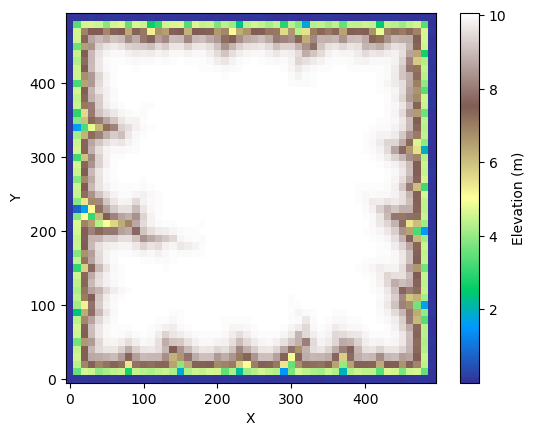

0.12 of model run completed


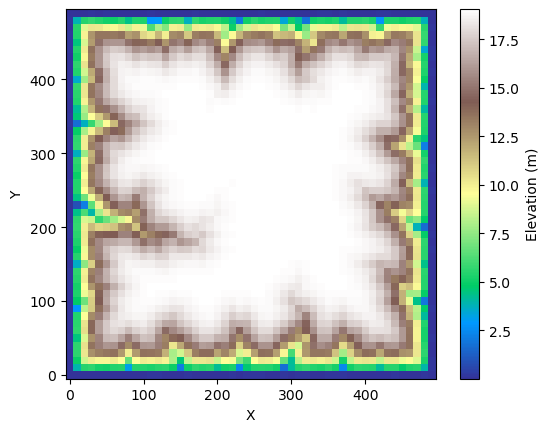

0.18 of model run completed


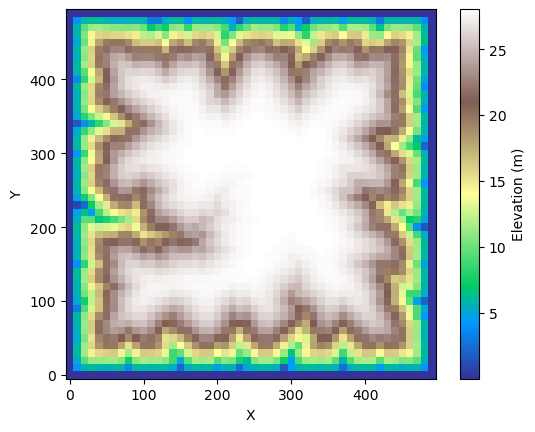

0.24 of model run completed


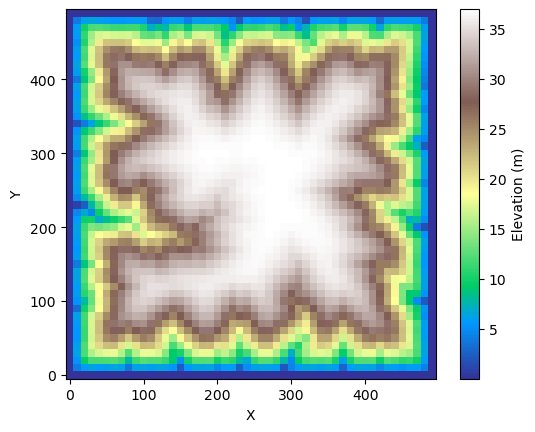

0.30 of model run completed


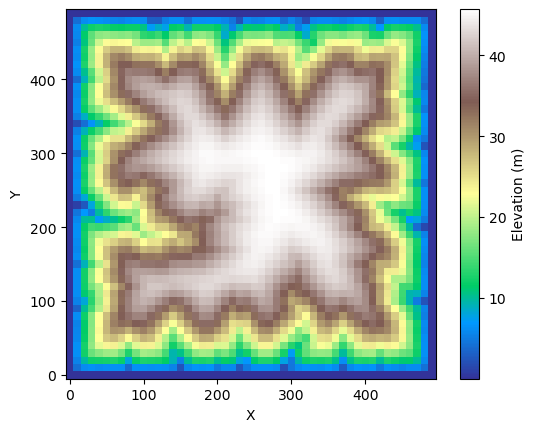

0.36 of model run completed


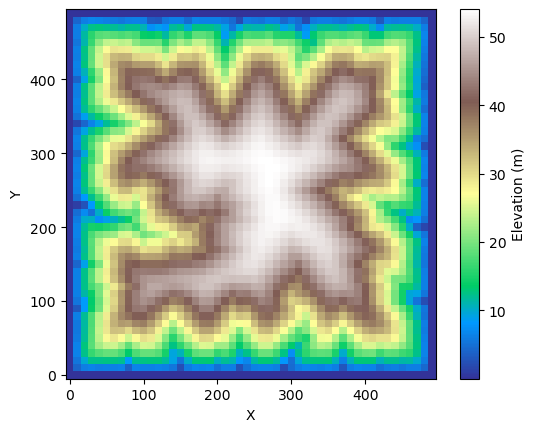

0.42 of model run completed


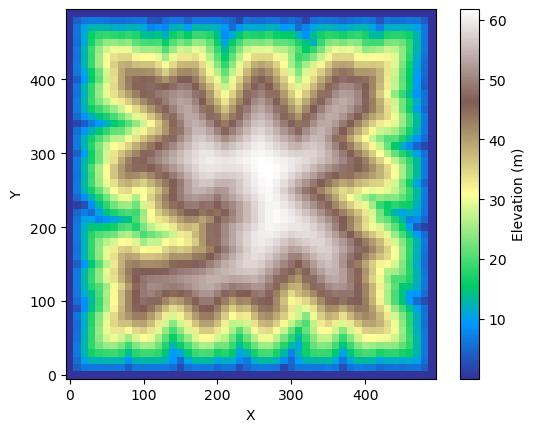

0.48 of model run completed


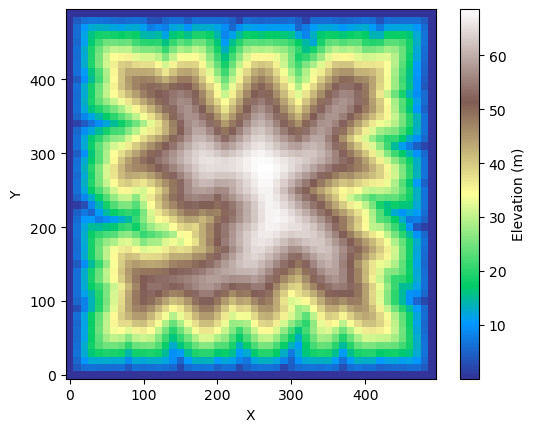

0.54 of model run completed


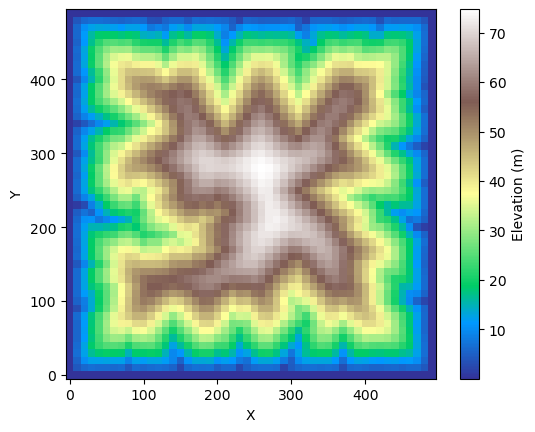

0.60 of model run completed


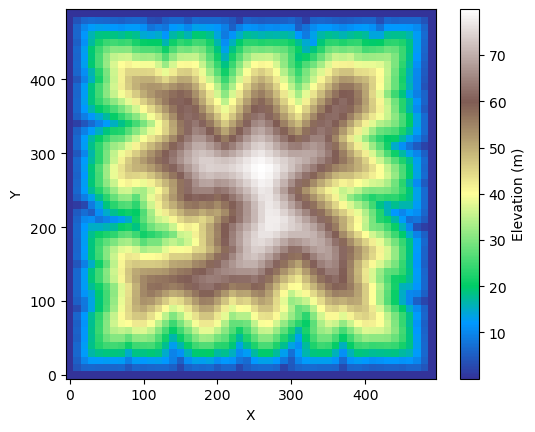

0.66 of model run completed


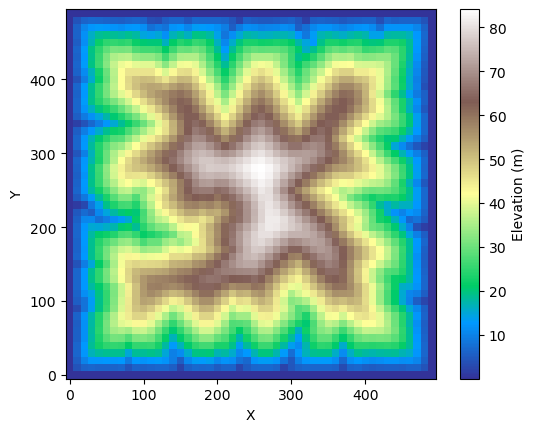

0.72 of model run completed


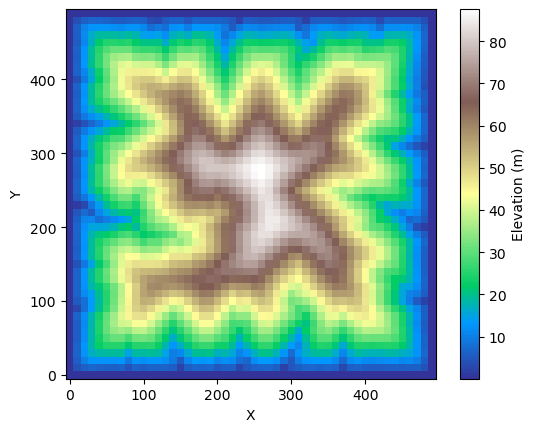

0.78 of model run completed


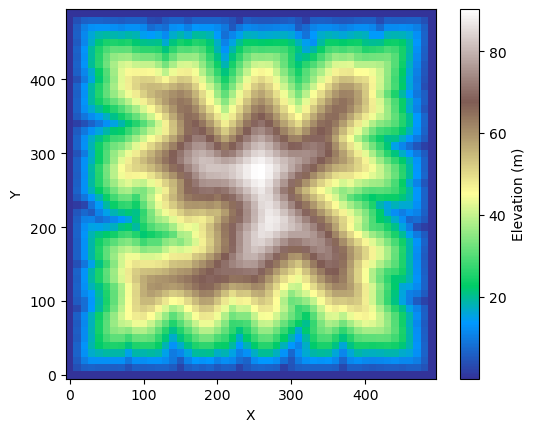

0.84 of model run completed


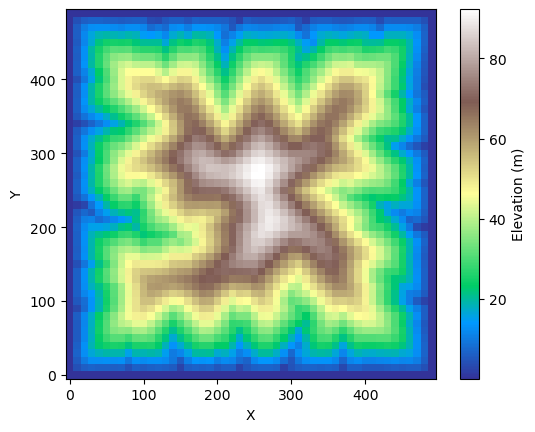

0.90 of model run completed


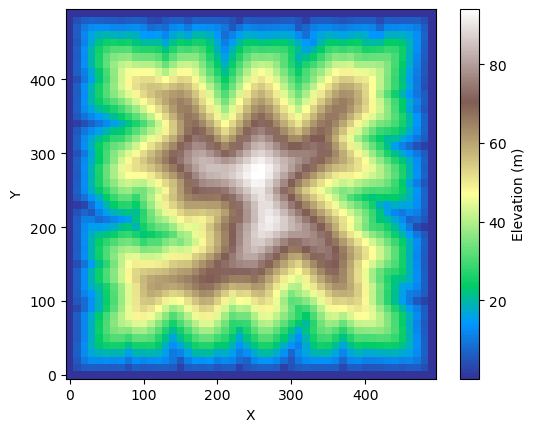

0.96 of model run completed


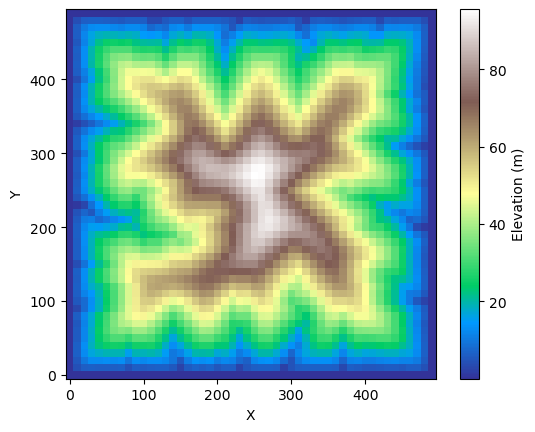

In [163]:
### Code Block 3 ###
# Run the model

# to run the model we loop through a number of time steps ndt, this will likely take a bit


# loop through all the timesteps

for i in range(ndt):
    # Update time counter
    elapsed_time += dt
    # add uplift to the bedrock
    mg.at_node['bedrock__elevation'][mg.core_nodes] += uplift_per_step

    # update topographic elevation to match bedrock and soil depths
    mg.at_node['topographic__elevation'][:] = (
        mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
    )
   
    # Run the processes
    ew.run_one_step(dt) # the exponential weatherer calculated how much soil is produced and how much bedrock is weathered from each cell 
    mg.at_node['soil__depth'][:] += mg.at_node['soil_production__dt_produced_depth'] # Then we manually add the soil
    mg.at_node['bedrock__elevation'][:] -= mg.at_node['soil_production__dt_weathered_depth'] # and subtract the bedrock
    mg.at_node['topographic__elevation'][:] = (mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]) #and make sure the total elevation matches

    fr.run_one_step()  #this script, perhaps ineficiantly recalculates slopes after weathering and diffusion
    ddTd.run_one_step(dt) # run the diffuser       
    fr.run_one_step()  #recalculate slopes and flow routing before running the fluvial eroder          
    eroder.run_one_step(dt) #run the fluvial eroder
    # Save the mean elevation of the time step to track progress
    Mean_elev.append(np.mean(mg.at_node['topographic__elevation'][mg.core_nodes])) # store the mean elevation of landscape

    # plot the topography if it's in a progress interval time step
    if np.mod(elapsed_time, progress_interval_years) == 0:
        print("%.2f of model run completed" % (elapsed_time / total_t))
        imshow_grid(
            mg, "topographic__elevation", cmap=cmapelev, colorbar_label="Elevation (m)"
        )
        plt.show()    
    

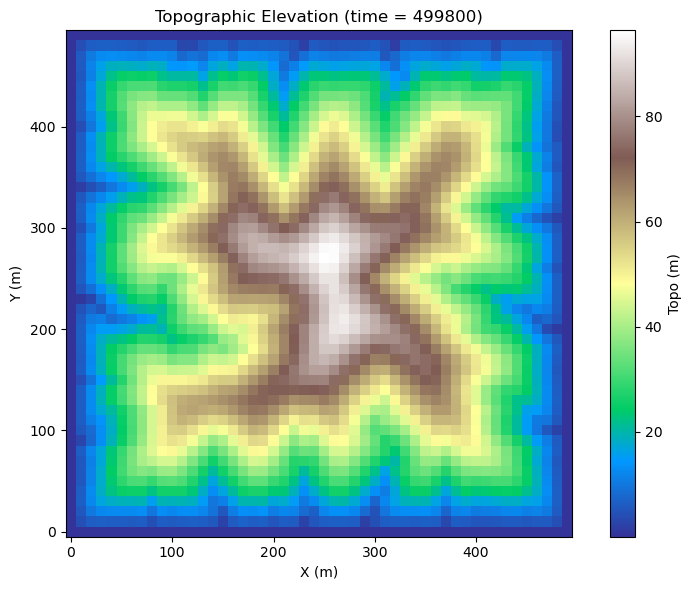

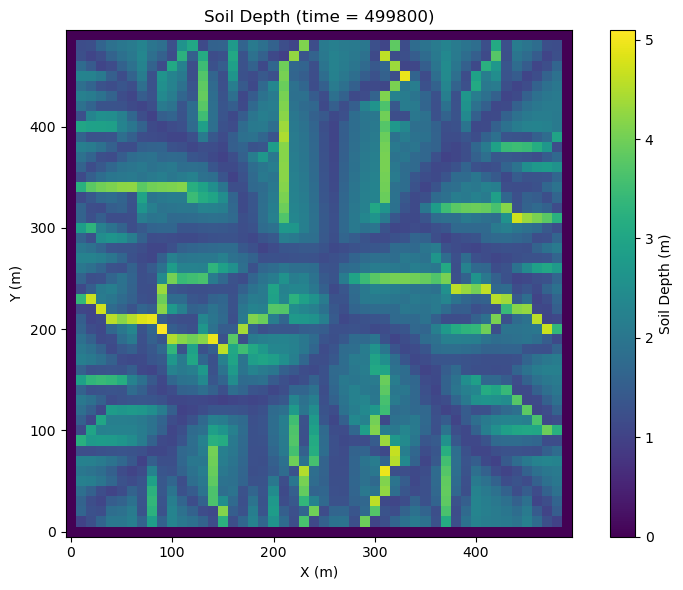

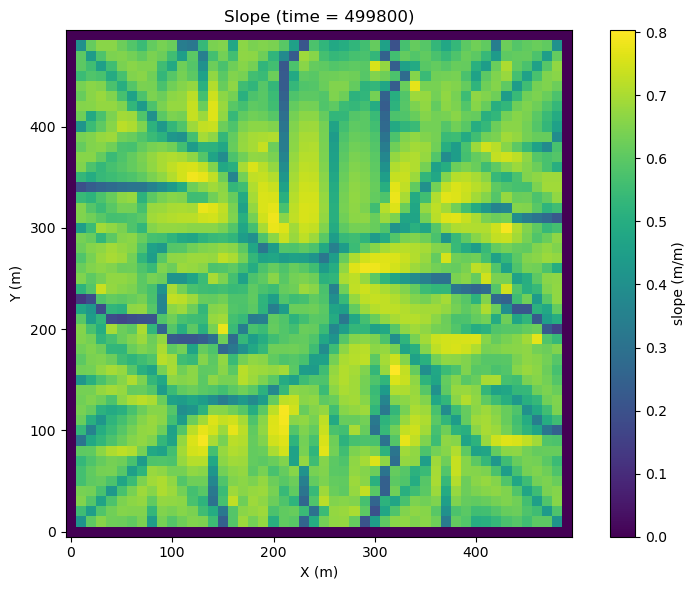

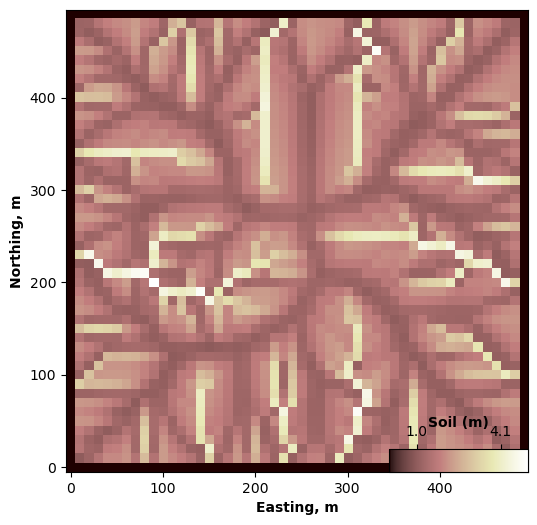

In [164]:
### Code Block 4 ###
# plots to visualize the simulated landscape

# --- Topographic elevation ---
plt.figure(figsize=(8, 6))
imshow_grid(
    mg,
    "topographic__elevation",
    var_name="Topo",
    var_units="m",
    grid_units=("m", "m"),
    cmap="terrain",
)
plt.title(f"Topographic Elevation (time = {elapsed_time})")
plt.tight_layout()
plt.show()

# --- Soil depth ---
plt.figure(figsize=(8, 6))
imshow_grid(
    mg,
    "soil__depth",
    var_name="Soil Depth",
    var_units="m",
    grid_units=("m", "m"),
    cmap="viridis",
)
plt.title(f"Soil Depth (time = {elapsed_time})")
plt.tight_layout()
plt.show()

# --- Slope ---
plt.figure(figsize=(8, 6))
imshow_grid(
    mg,
    "topographic__steepest_slope",
    var_name="slope",
    var_units="m/m",
    grid_units=("m", "m"),
    cmap="viridis",
)
plt.title(f"Slope (time = {elapsed_time})")
plt.tight_layout()
plt.show()



# Show Soil thickness draped over the shaded topographic relief
plt.figure(figsize=(8, 6))
imshowhs_grid(
    mg,
    "topographic__elevation",
    drape1=mg.at_node["soil__depth"],
    plot_type="Drape1",
    var_name="Soil",
    var_units=r"m",
    grid_units=("m", "m"),
    #cmap=cmapsoil,
    #ticks_km=False,
)
plt.show()

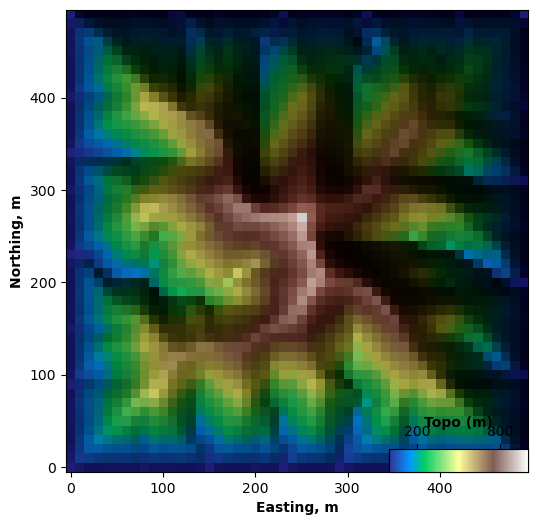

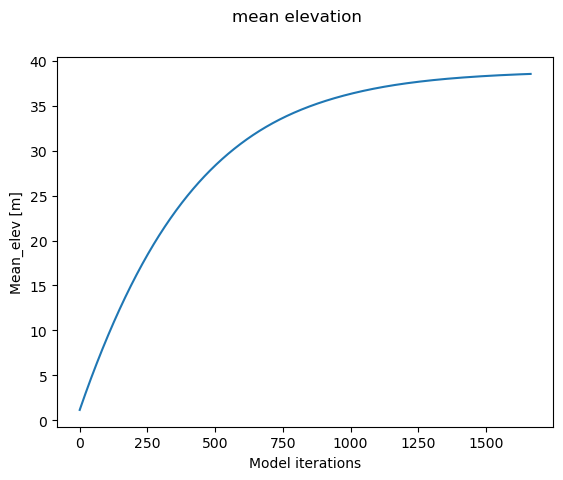

In [165]:
### Code Block 5 ###
#Hillshade and mean elevation plots to check steady state

# a topography hillshade plot
plt.figure(figsize=(8, 6))
imshowhs_grid(
    mg,
    "topographic__elevation",
    var_name="Topo",
    var_units=r"m",
    grid_units=("m", "m"),
    cmap=cmapelev,
    limits=(0,1000)
)
plt.show()

# Relief through time 
plt.suptitle("mean elevation")
plt.plot(Mean_elev)
plt.xlabel("Model iterations")
plt.ylabel("Mean_elev [m]")
plt.show()


## Part 2.1: Implimenting Soil Landslider

The SoilLandslider component simulates shallow landslides of only the uppermost soil layer. Please refer to Morgan et al., (In Prep) for a detailed model description with figures

#### Component - SoilLandslider 



#### Theory and governing equations
To function in a landscape evolution model, a landslide component must solve the following 4 questions: (1) Susceptibility: where is the hillslope unstable and prone to landsliding? (2) Trigger: when and where does the landslide happen? (3) Size: how big is the landslide source area, how is that determined? (4) Runout: where does the landslide material end up? 
##### __Susceptibility__
Soil landslide susceptibility is assessed using a factor of safety limit equilibrium equation based on the infinite slope stability model (equation 1). The derivation is similar to that of Montgomery and Dietrich, (1994); Hammond et al. (1998) and Strauch et al., (2018), except that we use the formulation for vertical measurements of soil depth ($H$) and relative wetness ($R_W$) rather than slope parallel in order to match built in Landlab outputs. This results in the factor of safety equation:

$$FS = \frac{\text{Shear Strength}}{\text{Shear stress}} = \frac{C + g H \cos^2(\theta)(\rho_{\text{soil}} - R_W * \rho_{\text{water}}) \tan(\phi)}{\rho_{\text{soil}} g H \cos(\theta)\sin(\theta)} \qquad \text{(Eq. 2.1)}$$

where $C$ is the effective cohesion ($\text{Pa}$ or $\text{N/m}^2$), $g$ is the gravitational constant ($9.81 \text{ m/s}^2$), $H$ is the vertical soil depth [soil__depth] ($\text{m}$), $\theta$ is the slope (Radians, note topographic__steepest_slope calculated by the flow router is in fractional slope m/m so is converted in the function), $R_W$ is the fraction of the vertical soil depth saturated by groundwater (1 is fully saturated), $\phi$ is the angle of internal friction ($\text{m/m}$), and $\rho_{\text{soil}}$ and $\rho_{\text{water}}$ are the densities of soil and water respectively. The $R_W$ fraction can be provided to the model two ways: either a set as a constant value across the entire grid of cells, or read in from each cell individually and calculated for each cell externally by the user.

##### __Trigger__
SoilLandslider triggers landslides through a critical cell based stochastic approach mostly following the methodology of Campforts et al. (2022). For every time step, each cell has a probability of trigger calculated by the temporal probability, ($0-1$ value). If this probability of failure is greater than a pseudo-random number between 0 and 1 then the cell will be selected as a possible critical node for the initiation of a landslide. If that node is also unstable as determined by the factor of safety (FS<1) then the cell will be a critical node representing the initiation of a landslide. 

The temporal probability is determined by a user-defined landslide return time (LRT) following Campforts et al., (2022). This LRT sets the temporal probability following a Poisson model for the probability of landslide occurrence during a set time period defined by the time step length (Crovelli, 2000). A larger LRT will result in a lower temporal probability for all cells and result in fewer landslides per model timestep.


$P_t = 1 - e^{-\frac{dt}{LRT}}$

Alternatively, critical nodes can be predetermined and provided to the model by their model grid node number. However, the model will only fail a predetermined critical node if the cell is determined to be unstable.

##### __Size__
Once a landslide is triggered at a critical node, that cell defines the failure plane of the landslide. A failure plane is projected uphill from the base of the soil layer on the critical node with an inclination defined by the steepest surface slope at the critical node. The landslide area grows by iterating through uphill neighbours of cells that have added to the erosional volume. When iterated to as an uphill neighbour, there are a few possibilities for each cell. 

1. If the failure plane intersects the cell below the surface but above the bedrock elevation only the soil above the failure plane is removed from the cell and added to the erosional volume and the failure continues to propagate uphill. 
2. If the failure plane intersects the cell below the top of the bedrock layer then all of the soil layer of that cell is removed and added to the erosional volume and the failure continues to propagate uphill. The bedrock above the failure plane is not removed and remains intact. 
3. If the failure envelope intersects a cells location above the surface of the soil than no material is eroded and the failure will stop propagating uphill (through that cell). This default case results in landslides that fail until the failure plane daylights at a ridge top.

While this is a generally reasonable assumption for bedrock landslides, soil landslides may be less likely to always fail to the hilltop (See Morgan et al., In Prep for more information). There are two ways to limit the propagation of failure before the failure surface reaches the ridgetop. 

* (A) The user can define a 'stable stopper' factor of safety value: if a cell has a factor of safety below the defined stable stopper value then no material will be eroded from that cell and the propagation will not continue through that cell to nodes uphill. 
* (B) The user can define a maximum step height that the landslide cannot pass through: if the bedrock elevation at the cell is greater than a maximum step height above the elevation of the failure plane at that location then no material will be eroded at that cell and the failure will stop propagating uphill through that cell. The max step height feature also limits propagation through strongly concave up landscapes.

##### __Runout__
For each landslide, the total eroded volume is summed from above the critical node, and then is deposited starting downhill of the critical node. Landslide runout and sediment deposition is deposited according to the same algorithm as implemented in Campforts et al. (2022),  which is modified from (Carretier et al., 2016). Landslide material cannot be deposited within the source area, but rather only downhill of the critical node. 

Material is deposited on cells downhill from the critical node according to their distance from the critical node and the slope of the cells. Deposition at a downslope cell does not occur if the cell’s slope is above a critical deposition threshold slope $S_{dt}$ (which is set by the user), and is instead deposited further downhill where this condition is met. Material is deposited downhill proportioned by the relative slopes to downhill cells using a multiple flow path flow routing algorithm (Barnes et al., 2014) until all the depositing sediment is depleted.

$$D_{sl} = \frac{Q_{sl}}{L} \tag{17}$$

where $D_{sl}$ $[\text{L T}^{-1}]$ represents the deposition flux per area and $Q_{sl}$ $[\text{L}^3\text{ T}^{-1}]$ represents the volumetric landslide-derived sediment discharge. The transport distance $L$ $[\text{L}]$ is calculated as:

$$L = \frac{dx}{1 - \left(\frac{S}{S_{dt}}\right)^2} \tag{18}$$

where $S$ is the slope angle $[\text{L L}^{-1}]$, $dx$ is a reference length scale for transport distance on a flat surface here set to $\Delta x$, and $S_c$ is a theoretically derived critical slope gradient $[\text{L L}^{-1}]$. 

##### __Relative Wetness__
In the Suscaeptibility calculation a key parameter is the Relative Wetness ($R_W$), representing the fraction of the soil layer that is saturated by groundwater.
$R_W$ can be provided to the model in two ways, either as a constant set value for all cells (Rw_mode = constant), or a value read in on a cell by cell basis from the grid, as calculated or specified by the user (Rw_mode = calculated). Here we provide a simple topographically controlled relative wetness calculation (following the example of Strauch et al., 2018) where the relative wetness at each cell is calculated by:

$$R_W = \frac{H_W}{H_S} = \frac{R \, A}{K_{Sat} H_S \sin(\theta)} \tag{2}$$

Where $H_W$ is the height of the water table, and $H_S$ is the height of the soil column (both perpendicular to the slope), R is the recharge rate (mm/d), A is the drainage area at a cell, $K_{Sat}$ is the saturated hydraulic conductivity (m/d), and $\theta$ is the slope. This groundwater model is impimented as a function defined and implimented in part 3. 


#### Input Parameters 
- **Angle of Internal Friction**, $\phi$, [angle_int_frict], [fractional slope m/m]: Sets the strength of the hillslope and relates to the slope at which a hillslope is unstable. (Montgomery et al., 2009) also found that friction angle values of ~40 degrees or ~0.8 (m/m) match recorded landslides in the Oregon Coast Range, which is what we use in the model

- **Effective Cohesion**, $C$, [cohesion_eff], [Pa or m-1s-2]: Another strength parameter of the hillslope, the effective Cohesion represents the cumulative cohesive forces holding the mass in place. Effective cohesion values (primarily due to lateral root strength) measured in the Oregon Coast Range vary greatly from 6.8-94 kPa depending on the logging history and forest type (Schmidt et al., 2001), though cohesion values of 0-1.8 kPa where found to match the saturated soil properties at the time of failure of a soil landslide within the coast (Montgomery et al., 2009). We choose a default value of 4 kPa (input at 4000 Pa in the model) for C.

- **Slope for deposition threshold**, $S_{dt}$, [threshold_slope], [fractional slope m/m]: The threshold slope (not to be confused with the critical slope for non-linear diffusion) sets the slopes that landslide material can begin to deposit. Campforts et al., (2022) used a value of 0.8 for their model runs that simulated deep seated bedrock landslides with the same runout algorithm. Keck et al., (2024) measured the surface slopes of several fresh landslide deposits in the field (including several in coastal ranges of Washington State) to calibrate a similarly functioning slope for material deposition and found depositional slopes ranging from 0.1 to 0.4 (m/m). To match the non-deposition locations of the Greenleaf landslide we chose a value of 0.3 (m/m).
  
- **Landslide Return Time**, $LRT$, [landslides_return_time],[yrs]: This parameter sets how often unstable cells fail. A larger LRT represents a larger time between landslides and thus less frequent landslides. Because the landslide frequency depends on the selected LRT and the grid resolution, grid size, and model setup it is difficult to approximate this parameter directly from recorded landslide frequency estimates  so users may wish to calibrate this return time after model runs. We find values of 20,000 years works to generate a reasonable amount of landslides, this is the same value chosen in (Campforts et al., 2020). . 

- **Relative wetness mode**  [Rw_mode]: Sets how the model will assign Rw values: "constant" - use the provided Rw value for all nodes (default), and "calculated"-read Rw values from the grid field "rel__wetness". None or unrecognized values defaults to constant Rw = 0.8
  
- **Relative Wetness** $Rw$ [Rw],[NA]: Wetness fraction of  height water column over height soil column (vertical). Used only if Rw_mode="constant". Value must be between 0 and 1. 
  
- **FS stable stopper** [stable_stopper_factor],[NA]:The factor of safety that is considered too stable for a slide to  propagate uphill through. Note FS<1 is still required to initiate failure. This parameter defaults to a high value of 5.

- **Maximum step height** [max_step_height],[m]:Maximum height of the bedrock elevation above the failure plane for the slide to erode the soil on top and continue. When set, this value will limit the propagation of the landslide uphill, in instances when uphill cells lie high above the failure plane which is set by the surface slope at the critical node. Note that because this value is in meters and not percent, it may be more likely to be triggered when the grid size is large.  The default of this parameter is False and for it to not be implimented. 



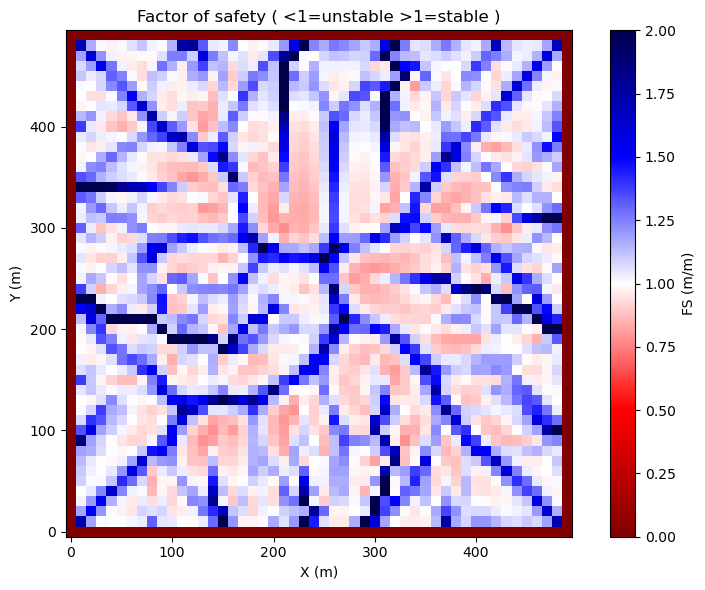

In [166]:
### Code Block 6 ###
# Now add in SoilLandslider and run one step on the landscape to plot the factor of safety

#import the component
from landlab.components import SoilLandsliderGeo

#define the input parameters
# SoilLandslider
angle_int_frict=0.8
threshold_slope=0.6
landslides_return_time=20000
verbose_landslides=False
cohesion_eff=4000
landslides_return_time_noslides=1000000000
landslides_return_time_regular=20000
max_step_height=75

#SoilLandslider groundwater parameterss
Rw_mode="constant"
Rw=0.8



# instantiate the component
# Note we are using the landslides_return_time_noslides return time,
# because we want to visualize the stability without any landslides in the first loop
sls=SoilLandsliderGeo(mg,
                                angle_int_frict=angle_int_frict,
                                landslides_return_time=landslides_return_time_noslides,
                                verbose_landslides=verbose_landslides,
                                cohesion_eff = cohesion_eff,
                                threshold_slope = threshold_slope,
                                #threshold_slope = None,
                                Rw=Rw,
                                Rw_mode=Rw_mode,
                                max_step_height=max_step_height,
                                )

# Then run one timestep with soillandslider
#we aren't looping through timesteps this time, because we're only running one timestep, 
# Run the processes
ew.run_one_step(dt)
mg.at_node['soil__depth'][:] += mg.at_node['soil_production__dt_produced_depth']
mg.at_node['bedrock__elevation'][:] -= mg.at_node['soil_production__dt_weathered_depth']
mg.at_node['topographic__elevation'][:] = (mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"])
fr.run_one_step()            # trying adding a new flow router run before soil creep, b/c was crashing...
ddTd.run_one_step(dt)
eroder.run_one_step(dt)

sls.run_one_step(dt=dt)
landslider=sls

# now plot the factor of safety results for the landscape
# --- factor of safety ---
plt.figure(figsize=(8, 6))
imshow_grid(
    mg,
    "factor_of_safety",
    var_name="FS",
    var_units="m/m",
    grid_units=("m", "m"),
    cmap="seismic_r",
    vmin=0,
    vmax=2,
)
plt.title(f"Factor of safety ( <1=unstable >1=stable )")
plt.tight_layout()
plt.show()

In [167]:
### Code Block 7 ###
# Now run a timestep with landslides

# because the landscape was built to steady state without landslides this may trigger many landslides

# set the time parameters
dt = 100
total_t = 100
ndt = int(total_t // dt)

# reinstantiate with a regular landslide return time
sls=SoilLandsliderGeo(mg,
                                angle_int_frict=angle_int_frict,
                                landslides_return_time=landslides_return_time_regular,
                                verbose_landslides=verbose_landslides,
                                cohesion_eff = cohesion_eff,
                                #threshold_slope = threshold_slope,
                                threshold_slope = None,
                                Rw=Rw,
                                Rw_mode=Rw_mode,
                                max_step_height=max_step_height,
                                )

# loop through all the timesteps
for i in range(ndt):
    # Update time counter
    elapsed_time += dt
     # add uplift with time-varying rate
    mg.at_node['bedrock__elevation'][mg.core_nodes] += uplift_per_step


    # update topographic elevation to match bedrock and soil depths
    mg.at_node['topographic__elevation'][:] = (
        mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
    )
   
    # Run the processes
    ew.run_one_step(dt)
    mg.at_node['soil__depth'][:] += mg.at_node['soil_production__dt_produced_depth']
    mg.at_node['bedrock__elevation'][:] -= mg.at_node['soil_production__dt_weathered_depth']
    mg.at_node['topographic__elevation'][:] = (mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"])

    
    fr.run_one_step()    
    ddTd.run_one_step(dt)        
    fr.run_one_step()            
    eroder.run_one_step(dt)
    sls.run_one_step(dt=dt)
    landslider = sls
    Mean_elev.append(np.mean(mg.at_node['topographic__elevation'][mg.core_nodes])) # store the mean elevation of landscape



This timestep there were 11 landslides with a mean area of 11.5 cells and a mean volume of 1404.3 meters cubed.


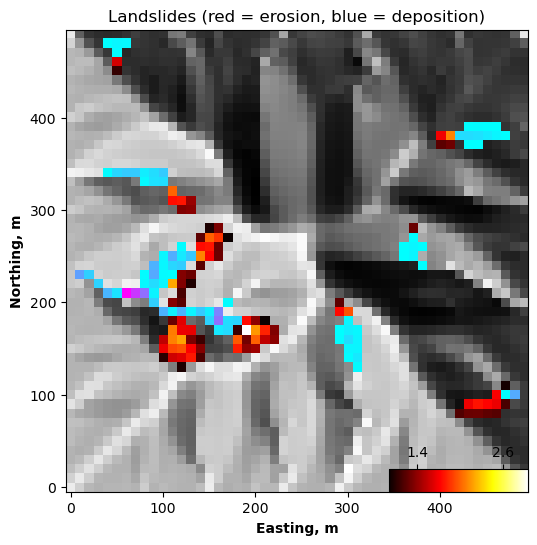

In [168]:
### Code Block 8 ###
# show the landslides

# grab stats saved by the landslider component
number_of_slides=np.size(landslider.landslides_size)
mean_landslides_area_cells=np.mean(landslider.landslides_size)
mean_landslides_volume=np.mean(landslider.landslides_volume)


print(
    f"This timestep there were {number_of_slides} landslides with a mean area of "
    f"{mean_landslides_area_cells:.1f} cells and a mean volume of {mean_landslides_volume:.1f} meters cubed."
)
#Plot the landslides
# the built in imshowhs function can be a little funky sometimes
# in this case only one color bar is plotted. 

fig = plt.figure(figsize=[8,6])
imshowhs_grid(
    mg,
    "topographic__elevation", # use the elevation for the hillshade
    drape1=mg.at_node["landslide__erosion"],  # plot landslide erosion
    drape2=mg.at_node["landslide__deposition"], #plot landslide deposition
    plot_type="Drape2", # drape two datasets in color over the hillshade
    thres_drape1 = (1), # for erosion only plot squares with more than 1m erosion
    thres_drape2 = (0.1), # for erosion only plot squares with more than 1m erosion
    var_name="Slide erosion",
    var_units=r"m",
    grid_units=("m", "m"),
    cmap="hot",
    cmap2="cool",
    #ticks_km=False,
    )

fig.axes[0].set_title("Landslides (red = erosion, blue = deposition)")
plt.show()          

## Part 2.2: Adding groundwater flow
Now we try adding in a shallow groundwater model

In [169]:
### Code Block 8 ###
#Implementing a shallow groundwater model
# See Relative wetness explanation

#here we have defined a simple relative wetness finder
# this function is based on 
def relativewetnessfinder(mg,recharge,Ksat):
    # read in data from the grid
    soil_d=mg.at_node['soil__depth'] # vertical soil depth
    S=mg.at_node['topographic__steepest_slope']
    da=mg.at_node['drainage_area']
   
    # Stop computational irregularities
    mg.at_node['topographic__steepest_slope'][np.where(S==0)] = 0.00001       # small slope at cells with no slope
    mg.at_node['drainage_area'][np.where(da==0)] = (mg.dx*mg.dy)   # contributing area of the first cell of the grid on hilltop. 
    
    
    hs =  soil_d / (np.cos(np.arctan(S))) # soil depth perpendicular to slope
    T = Ksat * hs # transmisivity is conductivity times thickness
    rel_wetness_perpendicular = (recharge / T) * (da / np.sin(np.arctan(S)) )
    rel_wetness_vertical = rel_wetness_perpendicular * np.cos(np.arctan(S))

    # Replace NaNs with 0
    rel_wetness_filled = np.nan_to_num(rel_wetness_vertical, nan=0.0)

    # Clip all values to the [0, 1] range
    rel_wetness_clean = np.clip(rel_wetness_filled, 0, 1)
    
    #save to grid
    mg.add_field('node','rel__wetness',rel_wetness_clean,clobber=True) # created a WI grid



/var/folders/lk/yw_6dx8x6vn5p268bg7pfnj00000gr/T/ipykernel_6075/1982389192.py:20: RuntimeWarning: divide by zero encountered in divide
  rel_wetness_perpendicular = (recharge / T) * (da / np.sin(np.arctan(S)) )
/var/folders/lk/yw_6dx8x6vn5p268bg7pfnj00000gr/T/ipykernel_6075/1982389192.py:30: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  mg.add_field('node','rel__wetness',rel_wetness_clean,clobber=True) # created a WI grid


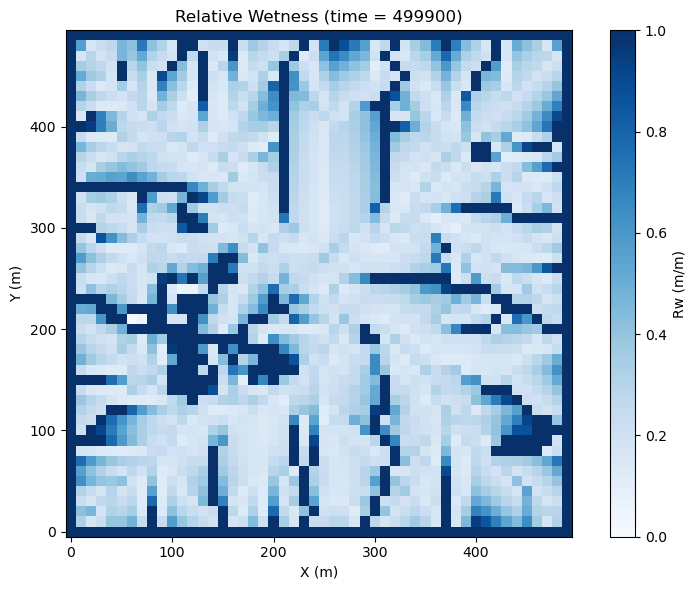

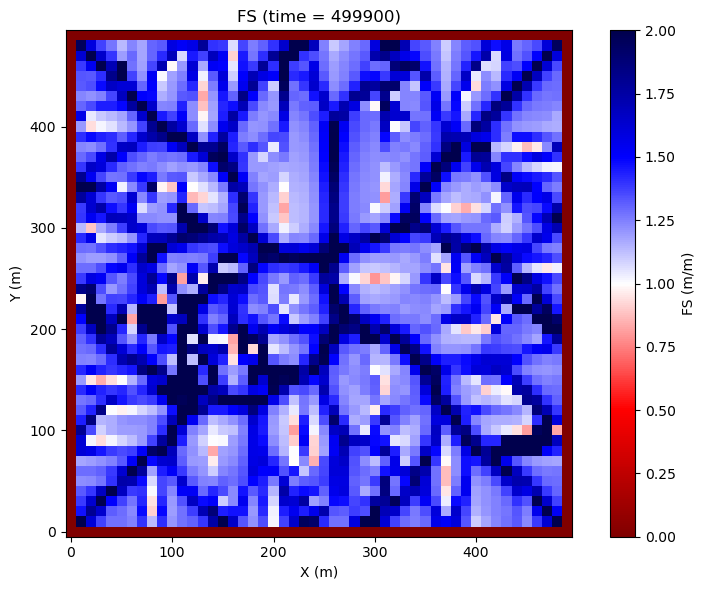

In [171]:
### Code Block 9 ###
# Reinstatiate SoilSlider and run it to visualize the groundwater saturation 

# redefine the soil landslider input paramters
# SoilLandslider
angle_int_frict=0.8
threshold_slope=0.6
landslides_return_time=20000
verbose_landslides=False
cohesion_eff=4000
landslides_return_time_noslides=1000000000
landslides_return_time_regular=20000
max_step_height=75

#SoilLandslider groundwater parameterss
Rw=0.8
Rw_mode="calculated"
recharge=0.001
Ksat=0.7


#reintantiate soilslider, with the new RW mode
# again we are using the noslides return time to visualize the landscape without triggereing slides
sls=SoilLandsliderGeo(mg,
                                angle_int_frict=angle_int_frict,
                                landslides_return_time=landslides_return_time_noslides,
                                verbose_landslides=verbose_landslides,
                                cohesion_eff = cohesion_eff,
                                #threshold_slope = threshold_slope,
                                threshold_slope = None,
                                Rw=Rw,
                                Rw_mode=Rw_mode,
                                max_step_height=max_step_height,
                                )


# then runone step with it 
# Run the processes
ew.run_one_step(dt)
mg.at_node['soil__depth'][:] += mg.at_node['soil_production__dt_produced_depth']
mg.at_node['bedrock__elevation'][:] -= mg.at_node['soil_production__dt_weathered_depth']
mg.at_node['topographic__elevation'][:] = (mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"])
fr.run_one_step()            # trying adding a new flow router run before soil creep, b/c was crashing...
ddTd.run_one_step(dt)
#fr.run_one_step()            
#sp.run_one_step(dt=dt)
eroder.run_one_step(dt)

#Because Soillandslider will read the RW value from the grid, we need to update this with our function each timestep
if Rw_mode == 'calculated':
                relativewetnessfinder(mg,recharge,Ksat)
#then run soillandslider 
sls.run_one_step(dt=dt)
landslider=sls

#Then plot the Relative wetness and factor of safety
# --- Relative wetness ---
plt.figure(figsize=(8, 6))
imshow_grid(
    mg,
    "rel__wetness",
    var_name="Rw",
    var_units="m/m",
    grid_units=("m", "m"),
    cmap="Blues",
    vmin=0,
    vmax=1,
)
plt.title(f"Relative Wetness (time = {elapsed_time})")
plt.tight_layout()
plt.show()

# --- factor of safety ---
plt.figure(figsize=(8, 6))
imshow_grid(
    mg,
    "factor_of_safety",
    var_name="FS",
    var_units="m/m",
    grid_units=("m", "m"),
    cmap="seismic_r",
    vmin=0,
    vmax=2,
)
plt.title(f"FS (time = {elapsed_time})")
plt.tight_layout()
plt.show()




Planning to stop there unless something more is essential?

In [ ]:
# optional extended run
# run for an extended time period
dt = 100
total_t = 10000
ndt = int(total_t // dt)

# loop through all the timesteps

for i in range(ndt):
    # Update time counter
    elapsed_time += dt
     # add uplift with time-varying rate
    mg.at_node['bedrock__elevation'][mg.core_nodes] += uplift_per_step


    # update topographic elevation to match bedrock and soil depths
    mg.at_node['topographic__elevation'][:] = (
        mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
    )
   
    # Run the processes
    ew.run_one_step(dt)
    mg.at_node['soil__depth'][:] += mg.at_node['soil_production__dt_produced_depth']
    mg.at_node['bedrock__elevation'][:] -= mg.at_node['soil_production__dt_weathered_depth']
    mg.at_node['topographic__elevation'][:] = (mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"])

    
    fr.run_one_step()    
    ddTd.run_one_step(dt)        
    fr.run_one_step()            
    eroder.run_one_step(dt)
    sls.run_one_step(dt=dt)
    landslider = sls
    Mean_elev.append(np.mean(mg.at_node['topographic__elevation'][mg.core_nodes])) # store the mean elevation of landscape
